Uploading librabries



In [24]:
!pip install factor_analyzer

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import scipy
import scipy.stats as stats
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from itertools import combinations
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score
from factor_analyzer import FactorAnalyzer
from sklearn.model_selection import cross_val_score

Uploading dataset and checking for NaN values:

In [26]:
file_name='/content/Cardiovascular_Disease_Dataset copy.csv'
data=pd.read_csv(file_name)
data.isnull().sum()

,0
patientid,0
age,0
gender,0
chestpain,0
restingBP,0
serumcholestrol,0
fastingbloodsugar,0
restingrelectro,0
maxheartrate,0
exerciseangia,0


Convert columns to proper data types.

In [27]:
data.head()
categ_cols=['gender', 'chestpain', 'fastingbloodsugar', 'restingrelectro', 'exerciseangia', 'slope', 'noofmajorvessels','target']
num_cols=["age",'restingBP',"serumcholestrol","maxheartrate","oldpeak"]
for col in categ_cols:
  data[col]=data[col].astype('category')
print("after formatting",'\n',data.dtypes)
data.describe()
data.columns

after formatting 
 patientid               int64
age                     int64
gender               category
chestpain            category
restingBP               int64
serumcholestrol         int64
fastingbloodsugar    category
restingrelectro      category
maxheartrate            int64
exerciseangia        category
oldpeak               float64
slope                category
noofmajorvessels     category
target               category
dtype: object


Index(['patientid', 'age', 'gender', 'chestpain', 'restingBP',
       'serumcholestrol', 'fastingbloodsugar', 'restingrelectro',
       'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels',
       'target'],
      dtype='object')

Summarise dataset for text report:

In [28]:
def summarize_dataframe(df):
    summary = {}
    for col in df.columns:
        col_data = {}
        if df[col].dtype in ['int64', 'float64']:
            col_data['Type'] = 'Numerical'
            col_data['Mean'] = df[col].mean()
            col_data['Min'] = df[col].min()
            col_data['Max'] = df[col].max()
            col_data['Std'] = df[col].std()
            col_data['Median'] = df[col].median()
        elif df[col].dtype == 'object' or df[col].dtype.name == 'category':
            col_data['Type'] = 'Categorical'
            col_data['Unique Values'] = df[col].unique().tolist()
            col_data['Value Counts'] = df[col].value_counts().to_dict()
        else:
            col_data['Type'] = 'Other'
            col_data['Unique Values'] = df[col].unique().tolist()
        summary[col] = col_data
    return pd.DataFrame.from_dict(summary, orient='index')
summarize_dataframe(data)


,Type,Mean,Min,Max,Std,Median,Unique Values,Value Counts
patientid,Numerical,5.048704e+06,103368.0,9990855.0,2.895905e+06,4952508.5,NaN,NaN
age,Numerical,4.924200e+01,20.0,80.0,1.786473e+01,49.0,NaN,NaN
gender,Categorical,NaN,NaN,NaN,NaN,NaN,"[1, 0]","{1: 765, 0: 235}"
chestpain,Categorical,NaN,NaN,NaN,NaN,NaN,"[2, 0, 1, 3]","{0: 420, 2: 312, 1: 224, 3: 44}"
restingBP,Numerical,1.517470e+02,94.0,200.0,2.996523e+01,147.0,NaN,NaN
serumcholestrol,Numerical,3.114470e+02,0.0,602.0,1.324438e+02,318.0,NaN,NaN
fastingbloodsugar,Categorical,NaN,NaN,NaN,NaN,NaN,"[0, 1]","{0: 704, 1: 296}"
restingrelectro,Categorical,NaN,NaN,NaN,NaN,NaN,"[1, 0, 2]","{0: 454, 1: 344, 2: 202}"
maxheartrate,Numerical,1.454770e+02,71.0,202.0,3.419027e+01,146.0,NaN,NaN
exerciseangia,Categorical,NaN,NaN,NaN,NaN,NaN,"[0, 1]","{0: 502, 1: 498}"


Variables descriptions:
- patientid: patient's number in the database (not relevant for the analysis)
- age: patient's age (in years)
- gender: sex of the patient (0 = female, 1 = male)
- chestpain: Chest pain subtypes (0,1,2,3)
- restingBP: blood pressure when patient is at rest (measured in mmHg)
- serumcholestrol: level of cholesterol in blood (measured in mg/dL)
- fastingbloodsugar: blood sugar measured after fasting (0 is normal, 1 is bigger than normal level 120 mg/dL)
- restingrelectro: resting electrocardiogram (0 - normal, 1 and 2 abnormal)
- maxhearrate: maximum heart rate achieved (measured in bpm)
- exerciseangia: angina (chest pain) induced by exercise (0 - no chest pain after exercise, 1 chest pain appears after exercise)
- oldpeak: ST segment decrease caused by exercise, measured in mm (refer to the image from https://ecgwaves.com/st-segment-normal-abnormal-depression-elevation-causes/)
- slope: ST segment slope shape (0,1 - normal, 2,3 abnormal)
- noofmajorvessels: number of major vessels  (ranging from 0 to 4) visible in fluoroscopy
- target: Diagnosis of heart disease (0 = healthy, 1 = presence of heart disease).


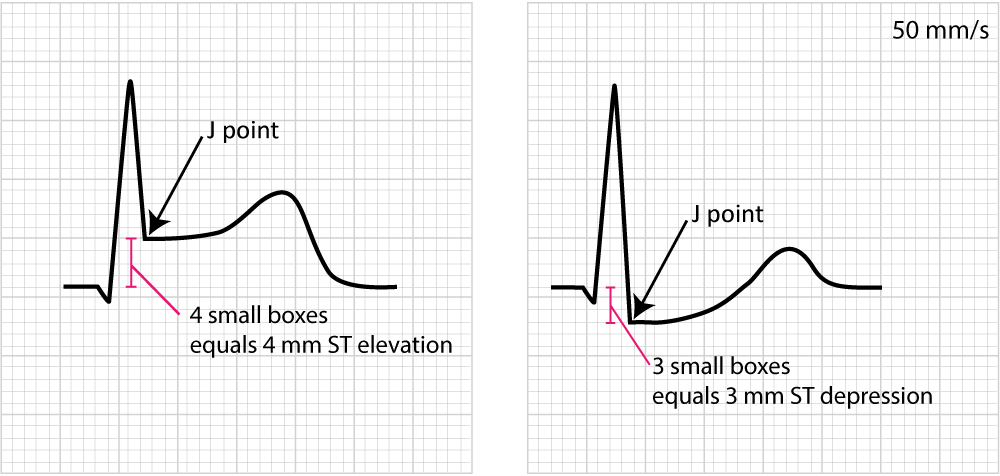

Normalise data:

In [29]:
#select only numercial variables
data_num=data[num_cols]
sc=StandardScaler()
data_norm=sc.fit_transform(data_num)
data_normalised=pd.DataFrame(data_norm,columns=num_cols,index=data.index)
# #check mean and std
print(data_normalised[num_cols].mean())
print(data_normalised[num_cols].std())
# data_normalised["target"] = data["target"]
print(data_normalised.head())
import scipy.stats as stats
dataANOVA=pd.DataFrame()
dataANOVA[categ_cols]=data[categ_cols]
dataANOVA[num_cols]=data_normalised[num_cols]


age                1.421085e-16
restingBP         -4.760636e-16
serumcholestrol   -2.486900e-17
maxheartrate      -1.119105e-16
oldpeak            9.769963e-18
dtype: float64
age                1.0005
restingBP          1.0005
serumcholestrol    1.0005
maxheartrate       1.0005
oldpeak            1.0005
dtype: float64
        age  restingBP  serumcholestrol  maxheartrate   oldpeak
0  0.210464   0.642833        -2.352717      0.044567  1.507245
1 -0.517591  -1.928098        -0.622817     -0.891840  0.576955
2 -0.013553  -0.625938        -1.280028      1.654017  1.332816
3 -0.349578  -0.458995        -0.124243      0.220143  0.286239
4 -1.021629   1.577717        -2.352717     -0.277323  1.507245


To be sure that there is no values of cholesterol level equal to 0 (min value in descriptive table is 0.0) that do not make sense:

In [35]:
data_cleaned = dataANOVA[dataANOVA['serumcholestrol'] != 0]
data_cleaned = data_cleaned.reset_index(drop=True)
print(f"Rows removed: {dataANOVA.shape[0] - data_cleaned.shape[0]}")

Rows removed: 0


# Numerical variables analysis
Box plots for numerical variables:

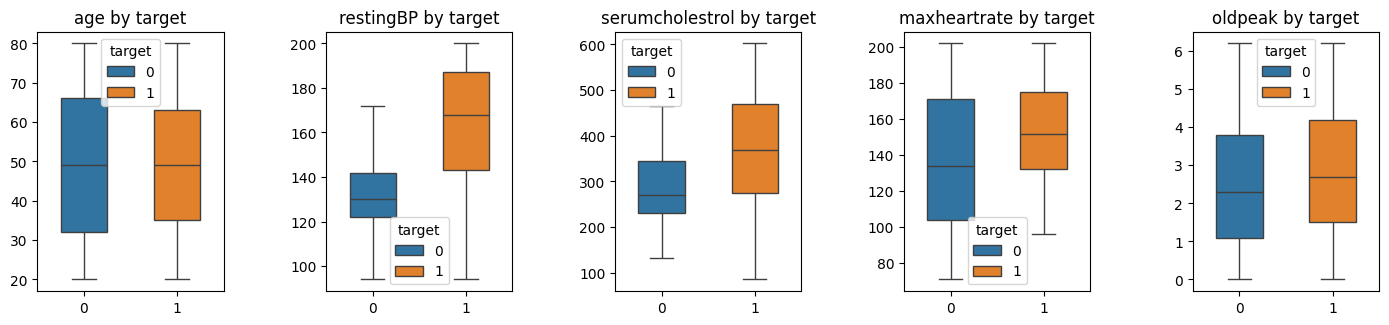

In [8]:
data = data[data['serumcholestrol'] != 0]
fig,axes=plt.subplots(nrows=1,ncols=5, figsize=(15, 4))
fig.tight_layout(pad=4)

for i,n_c in enumerate(num_cols):
  plot=sns.boxplot(x=data['target'], y=n_c, data=data, width=0.5, hue=data['target'], fliersize=0,ax=axes[i])
  plot.set_title(f"{n_c} by {'target'}")
  plot.set_xlabel("")
  plot.set_ylabel("")
plt.show()

I would like to see whether there is a significant difference between means/medians of numerical variables between sick and healthy individuals.
Check for normality of data for ANOVA by applying Shapiro-Wilk test:



In [21]:
import numpy as np

data_transformed = data[num_cols].copy()
for col in num_cols:
    data_transformed[col],_ = stats.boxcox(data[col] + 1) #

In [12]:
from scipy.stats import shapiro
features=num_cols
for feature in features:
    groups = [dataANOVA[dataANOVA['target'] == category][feature] for category in data['target'].unique()]
    for i, group in enumerate(groups):
        stat, p = shapiro(group)
        print(f"Feature: {feature}, Group {i}, Shapiro-Wilk p-value: {p}")

Feature: age, Group 0, Shapiro-Wilk p-value: 1.4550930837188092e-12
Feature: age, Group 1, Shapiro-Wilk p-value: 1.4751669246168034e-11
Feature: restingBP, Group 0, Shapiro-Wilk p-value: 6.205941866199969e-17
Feature: restingBP, Group 1, Shapiro-Wilk p-value: 1.8473256051690057e-14
Feature: serumcholestrol, Group 0, Shapiro-Wilk p-value: 5.906080571381199e-09
Feature: serumcholestrol, Group 1, Shapiro-Wilk p-value: 2.5584986094618266e-14
Feature: maxheartrate, Group 0, Shapiro-Wilk p-value: 5.226279487383029e-11
Feature: maxheartrate, Group 1, Shapiro-Wilk p-value: 1.1044476041794712e-09
Feature: oldpeak, Group 0, Shapiro-Wilk p-value: 1.3395052034727047e-11
Feature: oldpeak, Group 1, Shapiro-Wilk p-value: 8.894677865394432e-12


Since every p-value is very small I will try to transform the data using Box Cox transformation and check with visualisations what happens with data after Box Cox transformation and whether this can transform the data in a way that allows to use ANOVA.

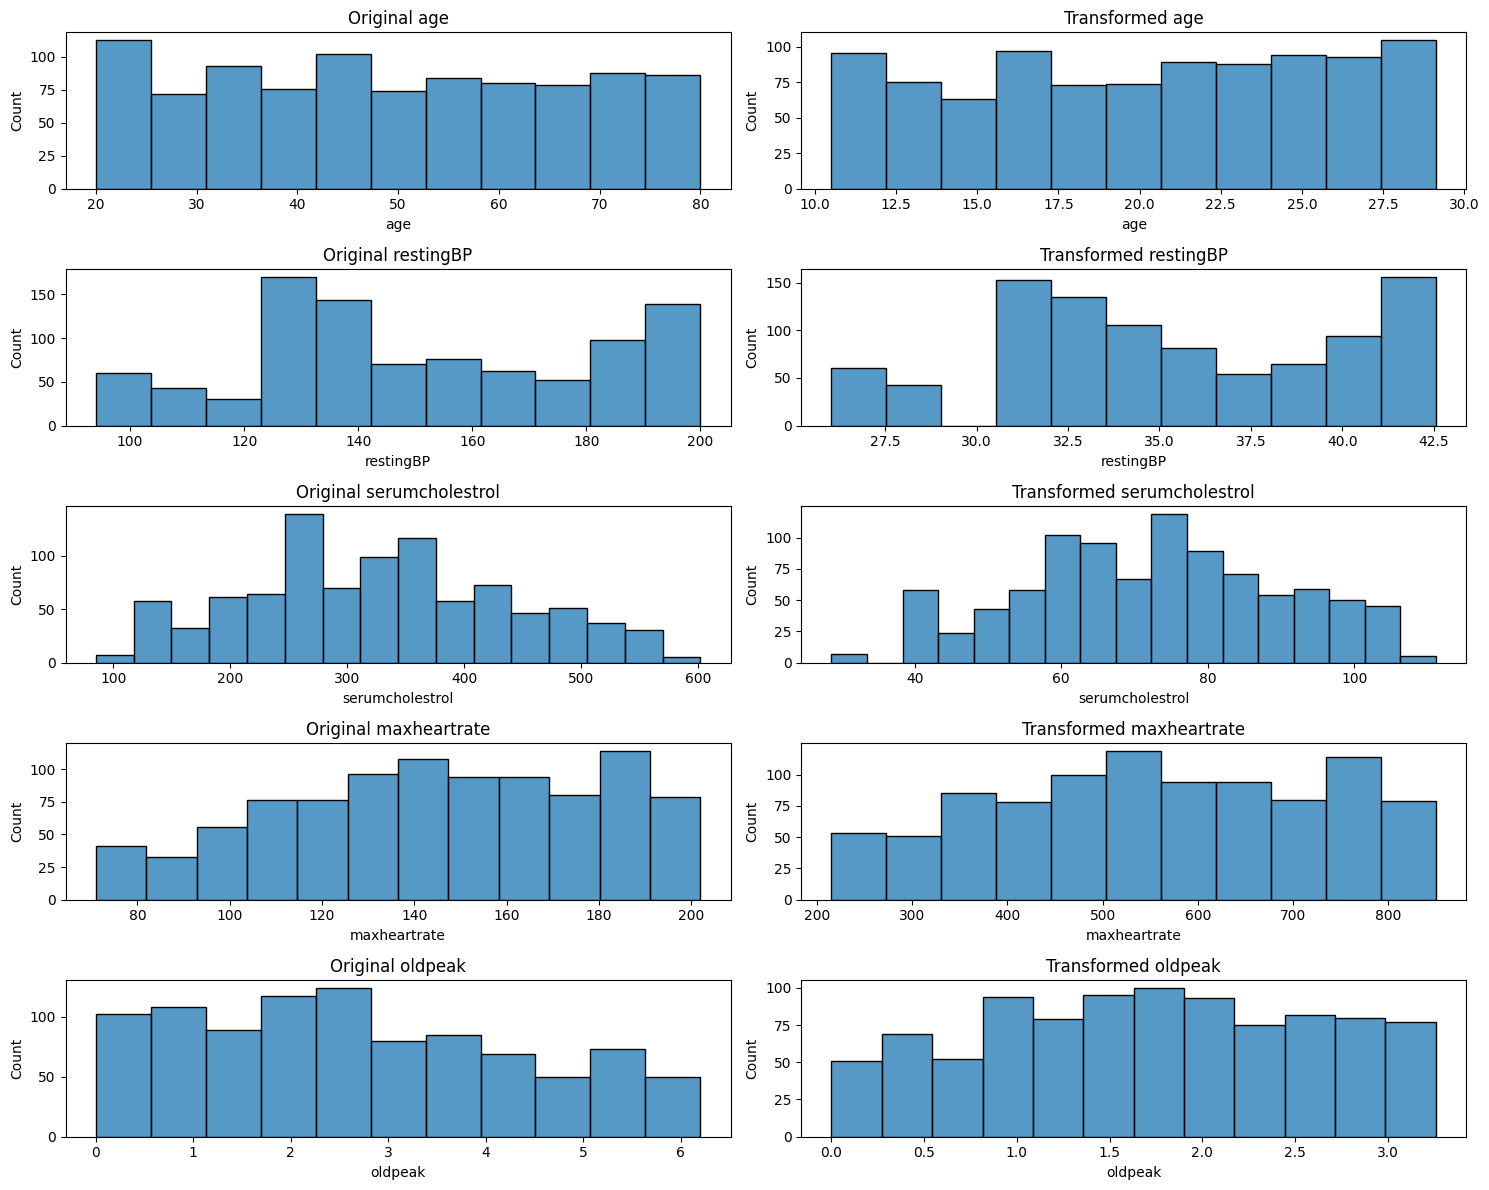

In [10]:
fig,axis=plt.subplots(5,2,figsize=(15,12))
for i,n_c in enumerate(num_cols):

  sns.histplot(x=data[n_c], data=data, ax=axis[i,0])
  sns.histplot(x=data_transformed[n_c], data=data, ax=axis[i,1])
  axis[i, 0].set_title(f"Original {n_c}")
  axis[i, 1].set_title(f"Transformed {n_c}")
fig.tight_layout()
fig.show()

Shapiro-Wilk test applied to transformed data:

In [18]:
data_transformed['target']=data['target']
for feature in features:
    groups = [data_transformed[data_transformed['target'] == category][feature] for category in data['target'].unique()]
    for i, group in enumerate(groups):
        stat, p = shapiro(group)
        print(f"Feature: {feature}, Group {i}, Shapiro-Wilk p-value: {p}")

Feature: age, Group 0, Shapiro-Wilk p-value: 1.7263728516912866e-12
Feature: age, Group 1, Shapiro-Wilk p-value: 8.190099529347962e-11
Feature: restingBP, Group 0, Shapiro-Wilk p-value: 3.014197005032705e-15
Feature: restingBP, Group 1, Shapiro-Wilk p-value: 8.003239457723571e-15
Feature: serumcholestrol, Group 0, Shapiro-Wilk p-value: 5.159369558458798e-10
Feature: serumcholestrol, Group 1, Shapiro-Wilk p-value: 9.187737492199502e-09
Feature: maxheartrate, Group 0, Shapiro-Wilk p-value: 1.727827678389108e-11
Feature: maxheartrate, Group 1, Shapiro-Wilk p-value: 4.740725864638861e-09
Feature: oldpeak, Group 0, Shapiro-Wilk p-value: 4.602754214321212e-09
Feature: oldpeak, Group 1, Shapiro-Wilk p-value: 1.8660171884052686e-08


P-values are still very small so I will apply PCA to numerical columns to get some information about them.

# Categorical variables analysis

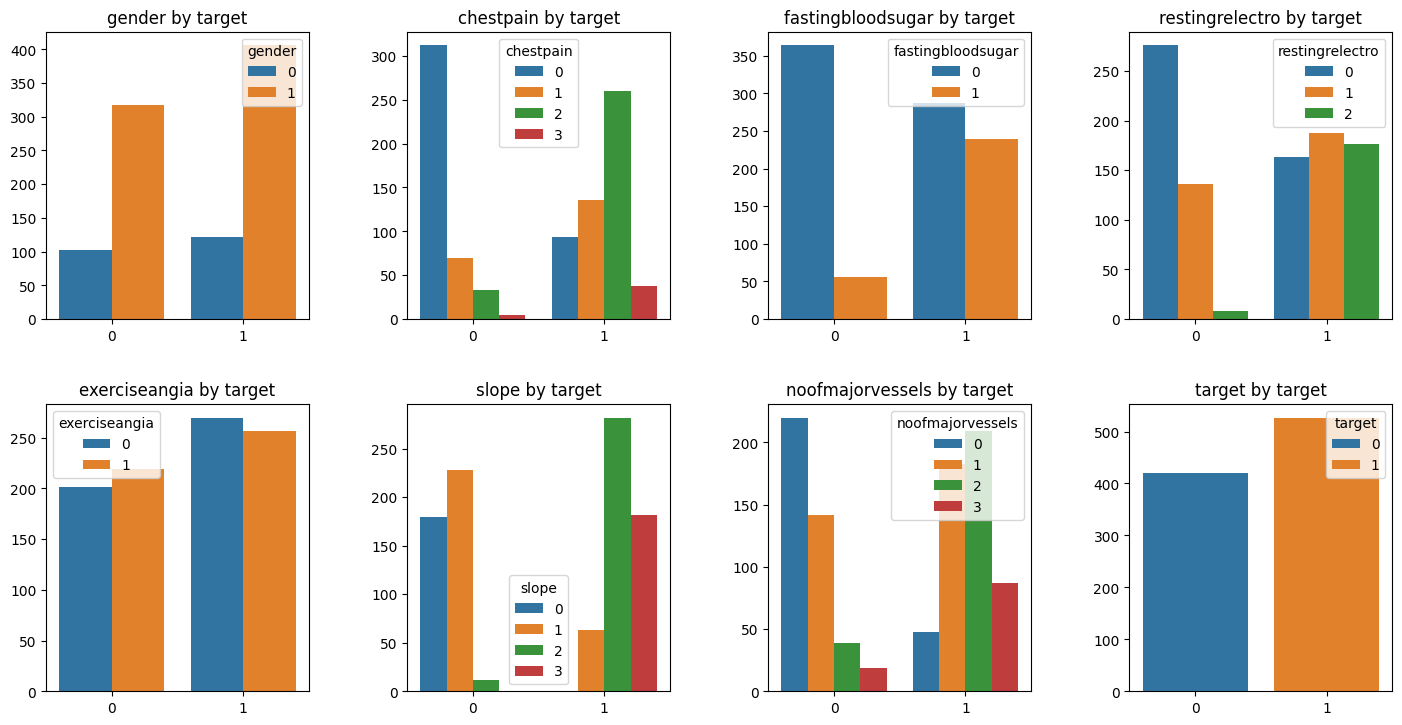

In [262]:
fig,axes=plt.subplots(nrows=2,ncols=4, figsize=(15, 8))
fig.tight_layout(pad=4)
for i,c_c in enumerate(categ_cols):
  ax=axes[i//4, i%4]
  plot=sns.countplot(x=data['target'], data=data, hue=data[c_c], ax=ax)
  plot.set_title(f"{c_c} by {'target'}")
  plot.set_xlabel("")
  plot.set_ylabel("")
plt.show()

Chi-squared test for categorical variables.

In [263]:
from scipy.stats import chi2_contingency
results_chi=[]
for c_c in categ_cols:
  if c_c=='target':
    continue
  contingency_table=pd.crosstab(data[c_c],data['target'])
  stat, p, dof, expected = chi2_contingency(contingency_table)
  results_chi.append({'col':c_c,'chi':stat,'p-value':p,'dfs':dof})
results_chi_df = pd.DataFrame(results_chi)
print(results_chi_df)

                 col         chi        p-value  dfs
0             gender    0.160433   6.887583e-01    1
1          chestpain  332.920763   7.440190e-72    3
2  fastingbloodsugar  111.342703   4.977736e-26    1
3    restingrelectro  181.045076   4.859161e-40    2
4      exerciseangia    0.934967   3.335756e-01    1
5              slope  700.367279  1.747429e-151    3
6   noofmajorvessels  267.034573   1.352136e-57    3


At least one of the categories for variables chestpain, fastingbloodsugar, restingrelectro, slope, numberofmajorvesseles is statistically significantly different between the group of sick individuals and healthy individuals at the significance level <0.05. Gender and exerciseangia are not different between healthy and sick patients.

# Principal Component Analysis (PCA) with only numerical variables
The next step is to make PCA to see whether groups of variables are common for sick and healthy subpopulations. For this, the data was first normalised.

[1.17947497 1.0737904  0.97597626 0.85562625 0.91513212]


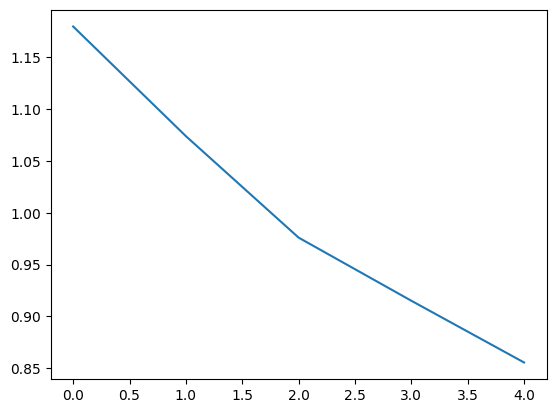

In [264]:
# data_PCA=data_normalised.drop('age',axis=1)
data_PCA=data_normalised
corrM = data_PCA.corr()
eigenvalues = np.linalg.eigvals(corrM)
eigenvalues_sorted = np.sort(eigenvalues)[::-1]
print(eigenvalues)
plt.plot(eigenvalues_sorted)
plt.show()

In [265]:
pca = PCA(n_components=2)
pca_cardiovascular = pca.fit_transform(data_PCA)
pca_cardiovascular_df = pd.DataFrame(data = pca_cardiovascular,
                                   columns = ['principal component 1', 'principal component 2'])
print('Explained variability per principal component: {}'.format(pca.explained_variance_ratio_))


Explained variability per principal component: [0.23589499 0.21475808]


I used 2 components since there are only 2 eigen values which are bigger than 1. Principal component 1 holds 23.5% of variability and principal component 2 holds 21.5% of variability.

In [309]:
pca_cardiovascular_df['target']=data['target']
pca_cardiovascular_df['target'].replace(0, 'Healthy',inplace=True)
pca_cardiovascular_df['target'].replace(1, 'Cardiovascular disease',inplace=True)

<ipython-input-309-686e18251df1>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-309-686e18251df1>:2: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

<ipython-input-309-686e18251df1>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an in

When assessing PCA components, every variable at least once has an absolute value of loading higher than 0.5. Therefore, it is sensible to consider all of these variables for a model.

In [268]:
# print('     restingBP serumcholestrol maxheartrate oldpeak')
print(data_PCA.columns)
pca_components = pd.DataFrame(pca.components_,
                              index=['PC1', 'PC2'])
print(pca_components)

Index(['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak'], dtype='object')
            0         1         2         3         4
PC1 -0.066136  0.661760  0.556009  0.497153  0.037320
PC2  0.591907  0.060988  0.387402 -0.391783 -0.585109


# Factor analysis with only numerical variables
Do factor analysis using code from https://www.geeksforgeeks.org/introduction-to-factor-analytics/

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



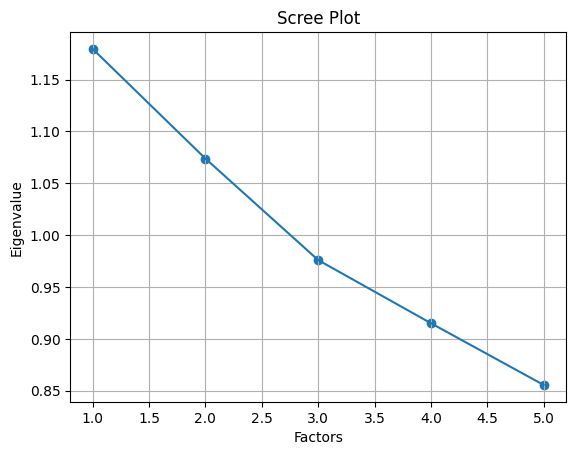

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [269]:
from factor_analyzer import FactorAnalyzer
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation="varimax")
fa.fit(data_normalised)
# Check Eigenvalues
eigen_values, vectors = fa.get_eigenvalues()
plt.scatter(range(1, data_normalised.shape[1]+1), eigen_values)
plt.plot(range(1, data_normalised.shape[1]+1), eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# Perform factor analysis with the determined number of factors
fa = FactorAnalyzer(n_factors=2, rotation="varimax")
fa.fit(data_normalised)
# Get variance of each factor
fa.get_factor_variance()

# Get factor scores
factor_scores = fa.transform(data_normalised)
# print(factor_scores)

Eigenvalues above 1 indicate 2 factors.

In [270]:
loadings = fa.loadings_
factors=['Factor1','Factor2']
df_factor_loading=pd.DataFrame(loadings,columns=factors)
num_cols=["age",'restingBP',"serumcholestrol","maxheartrate","oldpeak"]
vars=pd.Series(num_cols)
df_factor_loading['variable']=vars
print(df_factor_loading)


    Factor1   Factor2         variable
0  0.011660 -0.169597              age
1  0.358697  0.071809        restingBP
2  0.383461 -0.152446  serumcholestrol
3  0.211312  0.277886     maxheartrate
4 -0.018936  0.155617          oldpeak



- Loadings are small and probably factor analysis is not good for this data set. Maybe because there are not many variables in the data.
- Variables with bigger loading in Factor 1 are restingBP, serumcholesterol, and maxheartrate so this can be a factor with blood circulation.

Let's treat some of the ordinal categorical variables as numerical to see if there will be improvement in results for factor analysis. I will treat slope, chestpain, restingrelectro, and noofmajorvessels as numerical variables.
# Factor analysis with both numerical and categorical variables

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



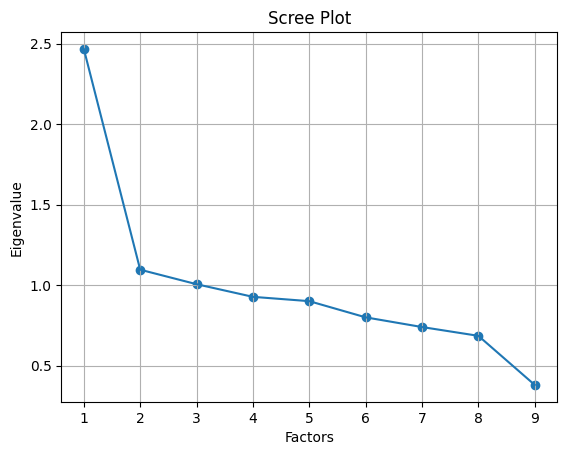

    Factor1   Factor2   Factor3          variable
0  0.762961  0.545971  0.005796             slope
1  0.451900  0.242404  0.262461         chestpain
2  0.387965  0.084750  0.200593   restingrelectro
3  0.505479  0.229774  0.049791  noofmajorvessels
4 -0.003201 -0.030822  0.249868               age
5  0.562904 -0.088527 -0.036041         restingBP
6  0.241895 -0.032227  0.183034   serumcholestrol
7  0.199415  0.107247 -0.036911      maxheartrate
8  0.035586  0.340889 -0.041316           oldpeak


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [271]:
varsforfa2=['slope','chestpain','restingrelectro','noofmajorvessels','age','restingBP','serumcholestrol','maxheartrate','oldpeak']
data_fa2=dataANOVA[varsforfa2]
# Create factor analysis object and perform factor analysis
fa2 = FactorAnalyzer(rotation="varimax")
fa2.fit(data_fa2)
# Check Eigenvalues
eigen_values, vectors = fa2.get_eigenvalues()
plt.scatter(range(1, data_fa2.shape[1]+1), eigen_values)
plt.plot(range(1, data_fa2.shape[1]+1), eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# Perform factor analysis with the determined number of factors
fa2 = FactorAnalyzer(n_factors=3, rotation="varimax")
fa2.fit(data_fa2)

# Get variance of each factor
fa2.get_factor_variance()

# Get factor scores
factor_scores = fa2.transform(data_fa2)
# print(factor_scorxes)
loadings2 = fa2.loadings_
factors=['Factor1','Factor2','Factor3']
df_factor_loading=pd.DataFrame(loadings2, columns=factors)
df_factor_loading['variable']=varsforfa2
print(df_factor_loading)


I took 3 factors since only till the 3rd factor the eigenvalues are bigger than 1.
- Variables with bigger loading in Factor 1 are slope, chestpain,noofmajorvessels, restingBP, and restingrelecto (weakly, >0.3) so this can be a factor connected with **heart function** (slope is shift in electrocardiogram during stress like exercise).
- Variables with bigger loading in Factor 2 are oldpeak (weakly, >0.3) and slope so this can be a factor connected with influence of **stress on electrocardiogram** (slope is shift in electrocardiogram during stress like exercise, oldpeak shows how much slope decreases during stress compared to rest).
- Variables with bigger loadings in Factor 3 are age, serumcholesterol, and chestpain so this can be an age factor.

# Correlation matrix

Finally, let's also take a look which variables correlate with the target the most.

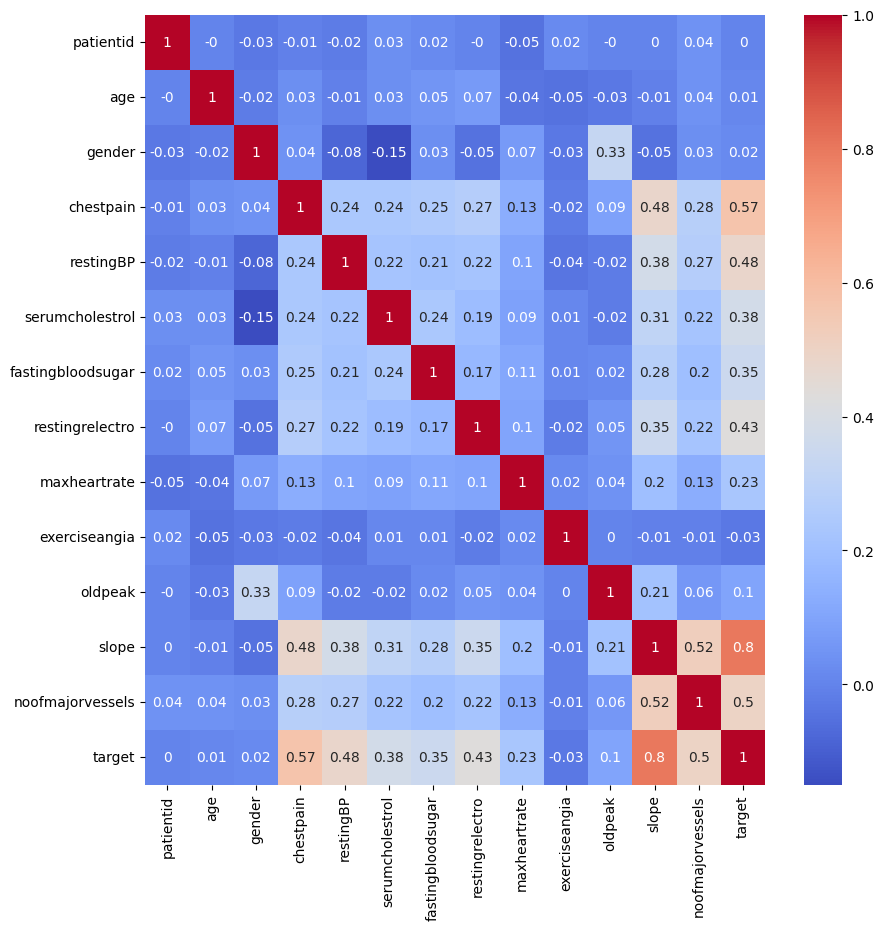

In [272]:
correlations = data.corr()
correlation_rounded = correlations.round(2)
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_rounded, annot=True, cmap="coolwarm")
plt.show()

# Selection of variables for Logistic regression (base model)
Variables with the correlation >|0.5| are chestpain, slope, and noofmajorvessels.
For the final model I will select categorical variables:
- chestpain
- slope
- noofmajorvessels
- restingrelectro

Because these variables are highly correlated with target and according to Chi-Squared test result they have a higher association with the target variable (chi-square statistics for slope is 700, for chestpain is 333, for noofmajorvessels is 267) at the significance level <0.05.

I will also use numerical variables:
- restingBP
- serumcholestrol
- maxheartrate
- oldpeak

All these variables had loadings bigger than 0.5 during the PCA analysis.

In [273]:
#function for assesment of models
def printScores(model, X, Y):
    y_pred=model.predict(X)
    cm = confusion_matrix(Y, y_pred)
    disp=ConfusionMatrixDisplay(cm)
    disp.plot()
    print("Model Accuracy:", accuracy_score(Y, y_pred))
    print("Classification Report:\n", classification_report(Y, y_pred))

# Logistic regression
First model is logistic regression with selected variables.

0.94 accuracy with a standard deviation of 0.02
Model Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        84
           1       0.97      0.97      0.97       116

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



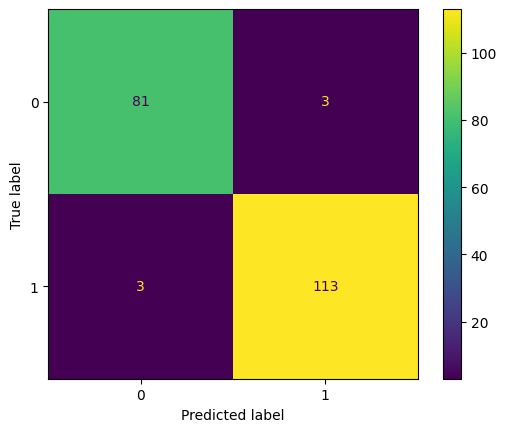

In [300]:
vars=['restingBP','serumcholestrol','maxheartrate','oldpeak','slope','chestpain','noofmajorvessels','target','restingrelectro']
data=dataANOVA[vars]
X_train,X_test,y_train,y_test = train_test_split(data.drop('target',axis=1),data['target'], test_size=0.2, random_state=42,stratify=data['target'])
logReg=LogisticRegression(random_state=42)
scores = cross_val_score(logReg, X_train, y_train, cv=5)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
logReg.fit(X_train, y_train)
# modelLogReg=logReg.fit(X_train,y_train)
printScores(logReg, X_test, y_test)

Logistic regression is good for predicting presence of cardiovascular disease with correctly predicting 113 out of 116 actually sick patients. The model also indicated 3 out 84 healthy people as sick.
Logistic regression has an accuracy of 0.97.

# Logistic regression model with factors from FA
In this model factors from factor analysis with numerical and categorical variables are used.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



0.94 accuracy with a standard deviation of 0.02
Model Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        83
           1       0.96      0.96      0.96       117

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



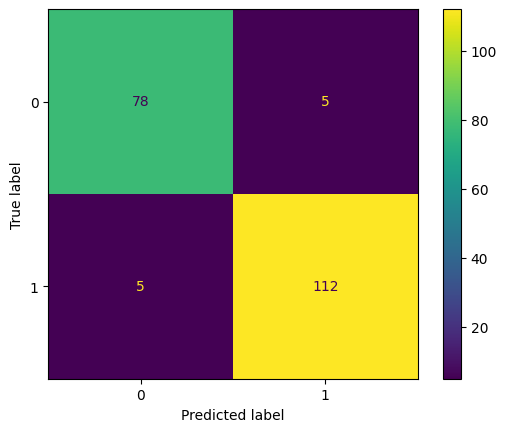

In [301]:

#Compute factor scores
factor_scores = fa2.transform(data_fa2)
factor_scores_df = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])
# print(data_fa2.shape,data['target'].shape)
factor_scores_df['target'] = data['target']

X = factor_scores_df.drop(columns=['target'])
y = factor_scores_df['target']

X_trainFA, X_testFA, y_trainFA, y_testFA = train_test_split(X, y, test_size=0.2, random_state=42)

logRegFa = LogisticRegression()
scores = cross_val_score(logRegFa, X_trainFA, y_trainFA, cv=5)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
# logReg.fit(X_train, y_train)
logRegFa=model.fit(X_trainFA, y_trainFA)
y_predFA = logRegFa.predict(X_testFA)
y_pred_probaFA = logRegFa.predict_proba(X_testFA)[:, 1]
printScores(logRegFa,X_testFA,y_testFA)

Logistic regression based on factors has an accuracy of 0.95 on test set. This model missclassified 5 out of 117 people, meaning 5 people were labeled healthy when they actually were sick. 5 out of 83 healthy people were indicated sick by the model.

# Logistic regression model with Principal components from PCA
First, I will do one-way ANOVA to see whether patients can be separated based on the first principal component.

In [302]:
import scipy.stats as stats
import pandas as pd

# Split dataset
sick = pca_for_model[pca_for_model['target'] == 1]
healthy = pca_for_model[pca_for_model['target'] == 0]

# Extract only PCA component columns
pca_components = [col for col in pca_for_model.columns if 'principal component ' in col]

# Perform ANOVA for each principal component
anova_results = []
for feature in pca_components:
    f_stat, p_value = stats.f_oneway(sick[feature], healthy[feature])
    anova_results.append({'Feature': feature, 'F-statistic': f_stat, 'p-value': p_value})

# Convert results to DataFrame for better readability
anova_df = pd.DataFrame(anova_results)
print(anova_df)


                 Feature  F-statistic       p-value
0  principal component 1   335.034879  9.355839e-65
1  principal component 2     1.259678  2.619819e-01


Apparently, first component's values are statistically significantly different between groups of healthy and sick individuals (p-value<0.05), while second component's values are are not with p-value of 0.262>0.05

I will use first principal component and train logistic regression model on it.

0.72 accuracy with a standard deviation of 0.04
Model Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71        83
           1       0.80      0.76      0.78       117

    accuracy                           0.75       200
   macro avg       0.74      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



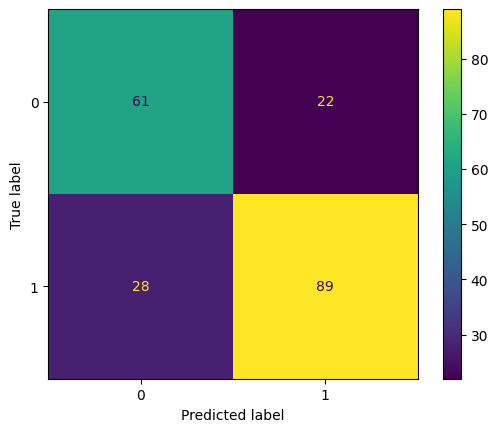

In [303]:
pca_for_model=pca_cardiovascular_df
pca_for_model['target']=data['target']

X =pca_for_model.drop(columns=['target','principal component 2'])
y = pca_for_model['target']
X_trainPCA, X_testPCA, y_trainPCA, y_testPCA = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()

scores = cross_val_score(logRegPCA, X_trainPCA, y_trainPCA, cv=5)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
logRegPCA=model.fit(X_trainPCA, y_trainPCA)

y_predPCA = logRegPCA.predict(X_testPCA)
y_pred_probaPCA = logRegPCA.predict_proba(X_testPCA)[:, 1]
printScores(logRegPCA,X_testPCA,y_testPCA)

Model with only the first principal component didn't work very well with accuracy of 0.75 on test data. This model didn't detect 28 out 117 sick people and labelled 22 out of 83 people sick even though they are healthy. I will add some categorical varibles (slope - 0.8, noofmajorvessels - 0.5, chestpain - 0.57, restingrelectro - 0.43) with significant correlation according to correlation matrix and train a new logistic regression model which uses first principal component and these four categorical variables.

0.94 accuracy with a standard deviation of 0.02
Model Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95        83
           1       0.97      0.96      0.97       117

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



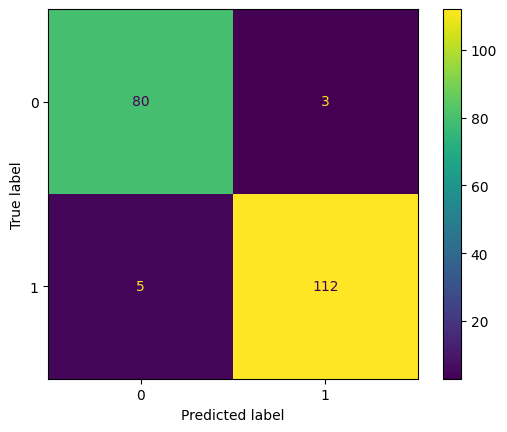

In [308]:
pca_for_model=pca_cardiovascular_df
pca_for_model['target']=data['target']

X =pca_for_model.drop(columns=['target','principal component 2'])
X['slope']=data['slope']
X['noofmajorvessels']=data['noofmajorvessels']
X['chestpain']=data['chestpain']
X['restingrelectro']=data['restingrelectro']
y = pca_for_model['target']
model = LogisticRegression()
X_trainPCA2, X_testPCA2, y_trainPCA2, y_testPCA2 = train_test_split(X, y, test_size=0.2, random_state=42)
scores = cross_val_score(model, X_trainPCA2, y_trainPCA2, cv=5)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
logRegPCA2=model.fit(X_trainPCA2, y_trainPCA2)


y_predPCA2 = logRegPCA2.predict(X_testPCA2)
y_pred_probaPCA2 = logRegPCA2.predict_proba(X_testPCA2)[:, 1]
printScores(logRegPCA2,X_testPCA2,y_testPCA2)

Adding categorical variables to principal component improved the model's accuracy and precision - 0.96 compared to 0.75. Only 5 out of 117 sick people were misclassified by model and 3 out of 83 healthy were labelled sick.

# Comparison of models
Comparison of models is discussed in detail in the text report.

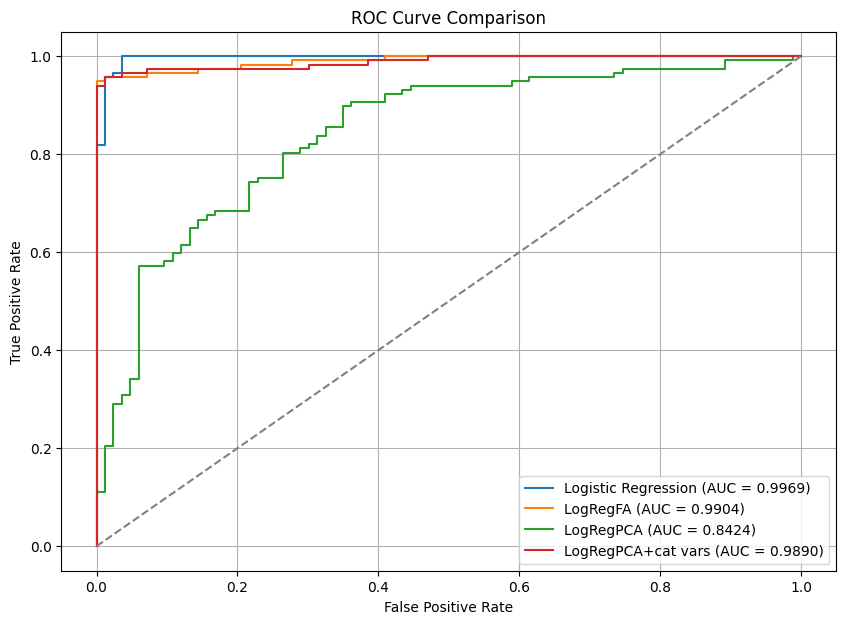

In [307]:
models = {
    "Logistic Regression": modelLogReg,
}
plt.figure(figsize=(10, 7))

# for name, model in models.items():
y_pred_proba = logReg.predict_proba(X_test)
y_pred_proba_class1 = y_pred_proba[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_class1)
auc = roc_auc_score(y_test, y_pred_proba_class1)
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

#factor analysis model
y_pred_proba_class1 = y_pred_proba2FA[:, 1]
fpr, tpr, _ = roc_curve(y_testFA, y_pred_probaFA)
auc = roc_auc_score(y_testFA, y_pred_proba_class1)
name='LogRegFA'
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# PCA with 1 component
y_pred_proba_class1PCA = y_pred_probaPCA
fpr, tpr, _ = roc_curve(y_testPCA, y_pred_probaPCA)
auc = roc_auc_score(y_testPCA, y_pred_proba_class1PCA)
name='LogRegPCA'
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# PCA with 1 component + categorical vars
y_pred_proba_class1PCA2 = y_pred_probaPCA2
fpr, tpr, _ = roc_curve(y_testPCA2, y_pred_probaPCA2)
auc = roc_auc_score(y_testPCA2, y_pred_proba_class1PCA2)
name='LogRegPCA+cat vars'
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()
